On a un pb de régression

modèles à essayer : régression linéaire, KNN, forets aléatoires, xgboost, réseaux de neuronnes
(notamment des RNN car séries temporelles)

mélangent de modèles ? 


QUESTIONNEMENT : 

- prédire les deux sorties à la fois ou les deux séparément ?
La question se pose surtout
pour les réseaux de neuronnes : des études ont montré que dans certains cas (je me rappelle plus lesquels)
cela améliore la performance car cela oblige le réseau de neuronnes à comprendre dans la profondeur les
données

- Quel retard choisir ?? 
Peut être choisir par validation croisée ? 

- peu de données ... 1000 observations --> attention au surapprentissage 








On importe les modules et packages nécessaires pour le on fonctionnement du code (peut être faire un 
requirements.txt puis pip install -r requirements.txt)

# Projet Informatique : Machine Learning 

## Etapes préliminaires

- importation des données 
- première visualisation
- création des pilotes
- test des pilotes (à faire), NB : Normalement les pilote 1 est bon

### Importation des modules nécessaires

In [2]:
#%pip install xgboost
#!brew install libomp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm
import seaborn as sns
import statsmodels.api as sm
import xgboost as xgb

### Chargement des données et première exploration des données mises à notre disposition

['Utr', 'Ytr', 'Uts1', 'Uts2']
Utr shape: (1000, 2)
Ytr shape: (1000, 2)
Uts shape: (1000, 2)
Uts2 shape: (1000, 2)
       Utr0      Utr1
0  1.225856  0.043213
1 -0.379083 -0.411898
2  0.683140 -0.921644
3  0.374853 -0.572683
4  0.256665 -0.760764
       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666


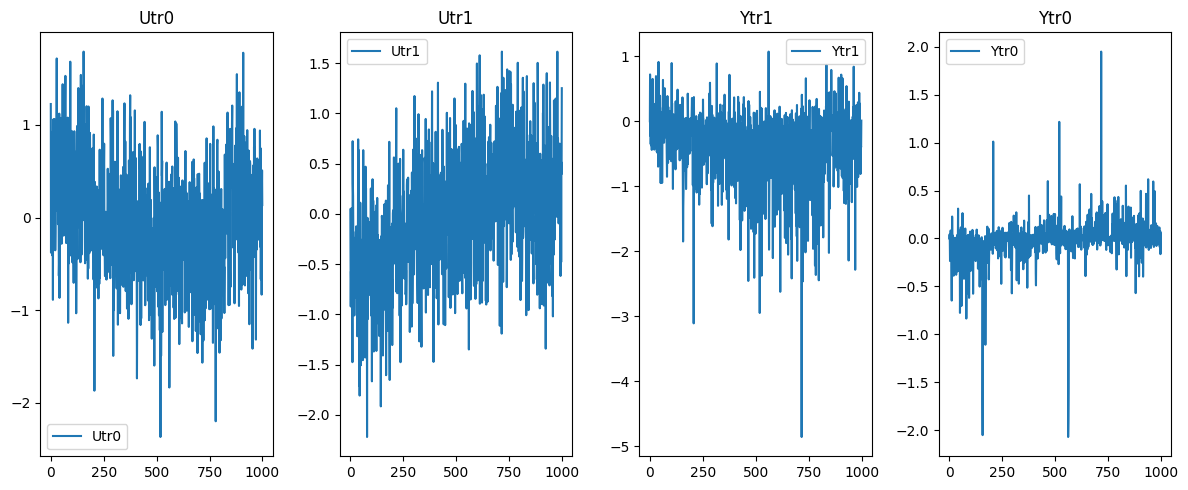

In [3]:
# Charger le fichier
data = np.load('StudentdataNARX.npz')

# Voir la liste des variables
print(data.files)

Utr = data['Utr']
Ytr = data['Ytr']
Uts = data['Uts1']
Uts2 = data['Uts2']

print("Utr shape:", Utr.shape)
print("Ytr shape:", Ytr.shape)
print("Uts shape:", Uts.shape)
print("Uts2 shape:", Uts2.shape)



# transformer les données de train en dataframe pandas
X = pd.DataFrame(Utr, columns=[f'Utr{i}' for i in range(Utr.shape[1])])
Y = pd.DataFrame(Ytr, columns=[f'Ytr{i}' for i in range(Ytr.shape[1])])
print(X.head(5))
print(Y.head(5))



figure, axes = plt.subplots(1, 4, figsize=(12, 5))
axes[0].plot(X['Utr0'], label='Utr0')
axes[0].set_title('Utr0')
axes[0].legend()
axes[1].plot(X['Utr1'], label='Utr1')
axes[1].set_title('Utr1')
axes[1].legend()
axes[2].plot(Y['Ytr1'], label='Ytr1')
axes[2].set_title('Ytr1')
axes[2].legend()
axes[3].plot(Y['Ytr0'], label='Ytr0')
axes[3].set_title('Ytr0')
axes[3].legend()
plt.tight_layout()
plt.show()


### Création des pilotes

**PILOTE NARX1**

          u
0  0.000000
1  1.490142
2 -0.414793
3  1.943066
4  4.569090
shape U (1001, 1)
0    0.000000
1    1.490142
2   -0.414793
3    1.943066
4    4.569090
5   -0.702460
6   -0.702411
7    4.737638
8    2.302304
9   -1.408423
Name: u, dtype: float64
         y1        y2
0  0.000000  0.000000
1  0.559742  0.369853
2  0.385331  0.570222
3  1.451077  0.730173
4  1.185748  1.828190
5  2.334884  2.352043
6  3.521816  1.253436
7  2.745450  0.380157
8  1.481447  3.173462
9  1.318939  2.635643
shape Y (1001, 2)
shape U (1001, 1)


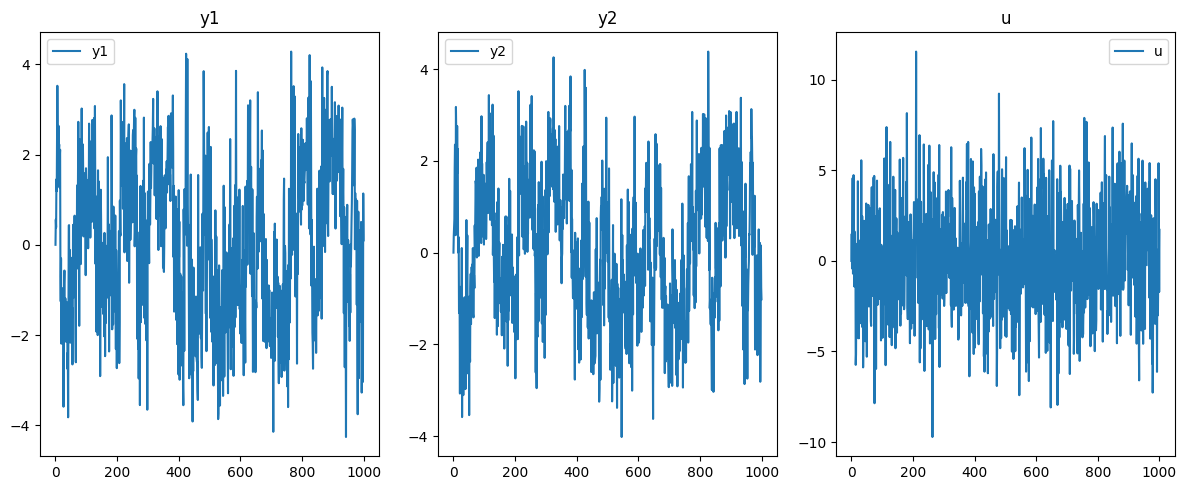

In [4]:

#simule NARX1 en pouvant choisir longueur (N) et variance du bruit
# dois etre mis en fonction car demande d'être flexible
def simulate_Narx1(n_points,sigma_noise,seed=42):

    np.random.seed(seed) # pour la reproductibilité

    # création des pilotes donnés dans l'énoncé
    # génération de U
    U_Narx1 = pd.DataFrame(np.zeros((n_points+1,1)),columns=['u']) #permet d'ajouter instant zéro pour y(0)=u(0)=0
    Y_Narx1 = pd.DataFrame(np.zeros((n_points+1,2)),columns=['y1', 'y2'])

    # générer U qui suit une distribution normale (moyenne 0, écart-type 3) : mon choix arbitraire
    U_Narx1.loc[1:,'u'] = np.random.normal(0, 3, size=n_points) #évite 4 lignes en plus
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    #U_Narx1.loc[0, 'u'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx1.loc[1, 'u'] = 0 # u0 = 0

    print(U_Narx1.head())
    print("shape U", U_Narx1.shape)
    print(U_Narx1['u'].head(10))


    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    #y1_minus_1 = 0
    #y2_minus_1 = 0
    #Y_Narx1.loc[0] = [y1_minus_1, y2_minus_1]
    Y_Narx1.loc[0] = [y1_0, y2_0]

    for i in range(1, n_points+1):

        # les indices seront réglés après la boucle
        y1_k2= Y_Narx1['y1'].iloc[i-2] if i-2>=0 else 0 #car iloc def de 0 à length-1 donc quand -1 pas bon
        y2_k2= Y_Narx1['y2'].iloc[i-2] if i-2>=0 else 0
        u_k2=U_Narx1['u'].iloc[i-2] if i-2>=0 else 0

        # deux formules données dans l'énoncé
        y1_i = 0.5 * y2_k2 + np.sin(Y_Narx1['y2'].iloc[i-1]) + 0.3 * u_k2 + np.random.normal(loc=0, scale=sigma_noise)
        y2_i = 0.5 * y1_k2 + np.sin(Y_Narx1['y1'].iloc[i-1]) + 0.2 * U_Narx1['u'].iloc[i-1] + np.random.normal(loc=0, scale=sigma_noise)
        Y_Narx1.loc[i] = [y1_i, y2_i]

    # enlever la première ligne qui correspond à y-1 et u-1et qui ont servi à générer les données
    #Y_Narx1 = Y_Narx1.drop(index=0).reset_index(drop=True)
    #U_Narx1 = U_Narx1.drop(index=0).reset_index(drop=True)

    return U_Narx1, Y_Narx1

n_points=1000
#verification si le bruit nulle
sigma1=0.4
U_Narx1, Y_Narx1 = simulate_Narx1(n_points,sigma1)

print(Y_Narx1.head(10))
print("shape Y", Y_Narx1.shape)
print("shape U", U_Narx1.shape)


# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx1['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx1['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx1['u'], label='u')
axes[2].set_title('u')
axes[2].legend()
plt.tight_layout()
plt.show()


- The indices are secured with the condition if i-2 >=0 because iloc(-1) (when k=0) is interpreted as the latest element of the array. However, the problem statement specifies that all previous values are zero. 
- The simulation is encapsulated in a functuion to allow for flexible simulation, enabling the definition of length and nooise variance.

**PILOTE NARX2**

         u1        u2
0  0.000000  0.000000
1  0.000000  0.000000
2  0.000000  0.000000
3  0.049671  0.139936
4 -0.013826  0.092463
shape U (1003, 2)
          y1        y2
0  -0.006752 -0.001445
1   0.132011  0.046592
2   0.073527 -0.011693
3   0.005968  0.055486
4  -0.057953  0.158281
5   0.053521 -0.030900
6   0.030582 -0.032740
7   0.095549  0.155009
8   0.060730  0.056389
9   0.108729 -0.058850
10 -0.051565  0.056323
11  0.144460 -0.058713
12 -0.010471 -0.044060
13  0.224165  0.036036
14 -0.066393 -0.192315
shape Y (1000, 2)
shape U (1000, 2)


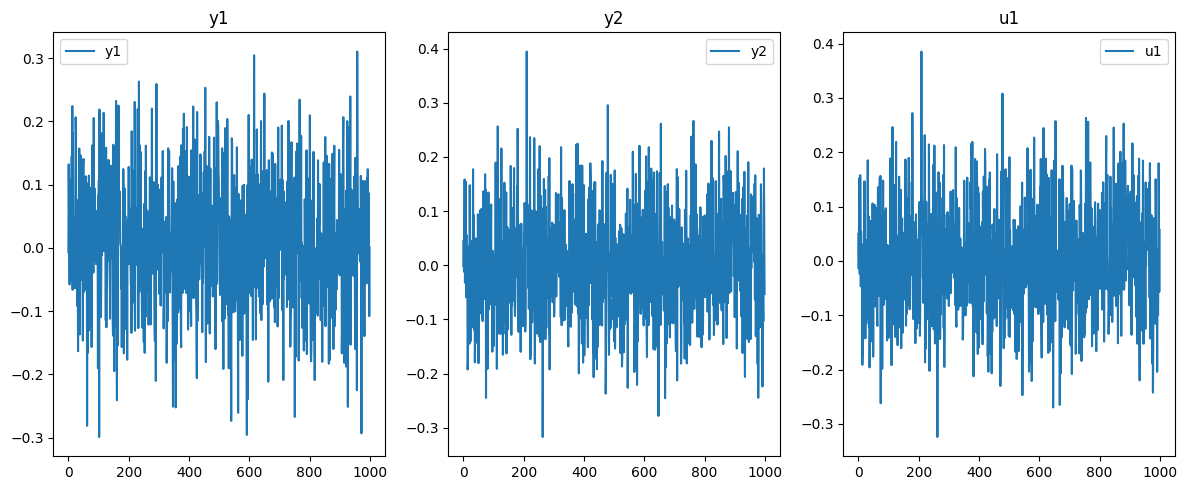

In [5]:
def simulate_Narx2(n_points,sigma_noise,seed=42):

    np.random.seed(seed) # pour la reproductibilité

    # génération de U (deux colonnes cette fois ci u1 et u2)
    U_Narx2 = pd.DataFrame(np.zeros((n_points+3,2)),columns=['u1', 'u2'])
    Y_Narx2 = pd.DataFrame(np.zeros((n_points+3,2)),columns=['y1', 'y2'])
    # générer U qui suit une distribution normale (moyenne 0, écart-type 0.1) : mon choix
    # arbitraire. Pour le coupp si je mets une trop grand evariance il y a explosion des données
    U_Narx2.loc[3:,'u1'] = np.random.normal(0, 0.1, size=n_points)
    U_Narx2.loc[3:,'u2'] = np.random.normal(0, 0.1, size=n_points)
    # n+1 points car on a u-1 qui doit être défini pour générer y1_1 et y2_1 :
    # on change sa valeur en 0 après
    # pa rapport à la génération de Y, pas besoin de remonter à u-2 (cf formules)
    #U_Narx2.loc[0, 'u1'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx2.loc[1, 'u1'] = 0 # u0 = 0
    #U_Narx2.loc[0, 'u2'] = 0 # pour respecter l'énoncé =u-1 = 0
    #U_Narx2.loc[1, 'u2'] = 0 # u0 = 0

    print(U_Narx2.head())
    print("shape U", U_Narx2.shape)


    # génération de Y
    # y1_0 = 0, y2_0 = 0 # cf énoncé : je me mets dans le m^me cas que les données réelles
    # à prédire (exo principal du projet)
    y1_0 = 0
    y2_0 = 0
    # y-1 = 0, y-2 = 0 # cf énoncé, nécessaire pour générer y1_1 et y2_1
    y1_minus_1 = 0
    y2_minus_1 = 0
    y1_minus_2 = 0
    y2_minus_2 = 0
    Y_Narx2.loc[0] = [y1_minus_2, y2_minus_2]
    Y_Narx2.loc[1] = [y1_minus_1, y2_minus_1]
    Y_Narx2.loc[2] = [y1_0, y2_0]
    # Bien faire attention à supprimer les 2 lignes à la fin et pas une seule
    # il faudra peut être les rajouter pour nos stratégies dans le futur (dépend de à quel point on souhaite
    # regarder le futur)


    for k in range(2, n_points+2): # on est décalé à 2 car on a ajouter y-1
        # les indices seront réglés après la boucle
        # deux formules données dans l'énoncé

        y1_k = Y_Narx2.loc[k, 'y1']
        y1_km1 = Y_Narx2.loc[k-1, 'y1']
        y1_km2 = Y_Narx2.loc[k-2, 'y1']

        y2_k = Y_Narx2.loc[k, 'y2']
        y2_km1 = Y_Narx2.loc[k-1, 'y2']
        y2_km2 = Y_Narx2.loc[k-2, 'y2']

        u1_k = U_Narx2.loc[k, 'u1']
        u1_km1 = U_Narx2.loc[k-1, 'u1']

        u2_k = U_Narx2.loc[k, 'u2']
        u2_km1 = U_Narx2.loc[k-1, 'u2']

        # Génération du bruit blanc w
        w1 = np.random.normal(0, sigma_noise)
        w2 = np.random.normal(0, sigma_noise)

        # Formule pour y1(k+1)
        num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
        den1 = 1 + y2_km1**2 + y2_km2**2
        y1_plus1 = (num1 / den1) + w1

        # Formule pour y2(k+1)
        num2 = y2_k * y2_km1 * y2_km2 * (y2_km2 - 1) * u1_km1 + u1_k
        den2 = 1 + y1_km1**2 + y1_km2**2
        y2_plus1 = (num2 / den2) + w2

        # Stockage du résultat à l'indice k+1
        Y_Narx2.loc[k+1] = [y1_plus1, y2_plus1]

    # enlever la première ligne qui correspond à y-1 et y-2 et u-1 qui ont servi à générer les données
    Y_Narx2 = Y_Narx2.drop(index=2).reset_index(drop=True)
    Y_Narx2 = Y_Narx2.drop(index=1).reset_index(drop=True)
    Y_Narx2 = Y_Narx2.drop(index=0).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=2).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=1).reset_index(drop=True)
    U_Narx2 = U_Narx2.drop(index=0).reset_index(drop=True)
    return U_Narx2, Y_Narx2
#fait la simu
sigma2=0.01 #0.02
U_Narx2, Y_Narx2 = simulate_Narx2(n_points, sigma2)

print(Y_Narx2.head(15))
print("shape Y", Y_Narx2.shape)
print("shape U", U_Narx2.shape)

# visualiser les données générées
figure, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].plot(Y_Narx2['y1'], label='y1')
axes[0].set_title('y1')
axes[0].legend()
axes[1].plot(Y_Narx2['y2'], label='y2')
axes[1].set_title('y2')
axes[1].legend()
axes[2].plot(U_Narx2['u1'], label='u1')
axes[2].set_title('u1')
axes[2].legend()
plt.tight_layout()
plt.show()


On a des données bornées, ce qui peut déjà limiter un peu l'explosion de l'erreur dû à la prédiction de 
1000 pts à la fois

### Tests des pilotes 

La phase de vérification a pour but de valider l'intégrité de notre générateur de données (les fonctions simulate).
Nous cherchons à démontrer que pour n'importe quel instant $t$, la valeur de sortie $y(t)$ enregistrée dans notre dataset correspond 
à l'application de la formule théorique du projet en utilisant les valeurs passées ($t-1, t-2, \dots$) présentes dans ce même dataset.


In [48]:
def verify_narx1(U, Y, nb_lignes=5):

    lignes = np.random.randint(2, len(Y), size=nb_lignes)

    for L in lignes:
        # Valeurs réelles à l'instant L
        y1_reel = Y.loc[L, 'y1']
        y2_reel = Y.loc[L, 'y2']

        # Pilotes (Indices k-1 et k-2)
        y1_km1, y2_km1 = Y.loc[L-1, 'y1'], Y.loc[L-1, 'y2']
        y1_km2, y2_km2 = Y.loc[L-2, 'y1'], Y.loc[L-2, 'y2']
        u_km1, u_km2   = U.loc[L-1, 'u'],  U.loc[L-2, 'u']

        # Calcul
        theorie1 = 0.5 * y2_km2 + np.sin(y2_km1) + 0.3 * u_km2
        theorie2 = 0.5 * y1_km2 + np.sin(y1_km1) + 0.2 * u_km1

        print("\nLigne" , L)
        print("y1 : Tableau:", y1_reel, ", Théorie:", theorie1, ", Écart:", abs(y1_reel - theorie1))
        print("y2 : Tableau:", y2_reel, ", Théorie:", theorie2, ", Écart:", abs(y2_reel - theorie2))

#test
verify_narx1(U_Narx1, Y_Narx1)



def verify_narx2(U, Y, nb_lignes=5):

    lignes = np.random.randint(3, len(Y), size=nb_lignes)

    for L in lignes:
        # Valeurs réelles à l'instant L (correspond à k+1 dans ta boucle)
        y1_reel = Y.loc[L, 'y1']
        y2_reel = Y.loc[L, 'y2']

        # Définition des indices
        k, km1, km2 = L-1, L-2, L-3

        # Récupération des pilotes
        y1_k, y1_km1, y1_km2 = Y.loc[k, 'y1'], Y.loc[km1, 'y1'], Y.loc[km2, 'y1']
        y2_k, y2_km1, y2_km2 = Y.loc[k, 'y2'], Y.loc[km1, 'y2'], Y.loc[km2, 'y2']
        u1_k, u1_km1 = U.loc[k, 'u1'], U.loc[km1, 'u1']
        u2_k, u2_km1 = U.loc[k, 'u2'], U.loc[km1, 'u2']

        # Formule y1(k+1)
        num1 = y1_k * y1_km1 * y1_km2 * (y1_km2 - 1) * u2_km1 + u2_k
        den1 = 1 + y2_km1**2 + y2_km2**2
        t1 = num1 / den1

        # Formule y2(k+1)
        num2 = y2_k * y2_km1 * y2_km2 * (y2_km2 - 1) * u1_km1 + u1_k
        den2 = 1 + y1_km1**2 + y1_km2**2
        t2 = num2 / den2

        print("\nLigne ",L )
        print("y1 : Tableau:", y1_reel, ", Théorie:", t1, ", Écart:", abs(y1_reel - t1))
        print("y2 : Tableau:", y2_reel, ", Théorie:", t2, ", Écart:", abs(y2_reel - t2))

#test
verify_narx2(U_Narx2, Y_Narx2)


Ligne 383
y1 : Tableau: -0.27077658563073026 , Théorie: -0.1723515903787508 , Écart: 0.09842499525197945
y2 : Tableau: 1.803032728052552 , Théorie: 2.1403313661790286 , Écart: 0.33729863812647665

Ligne 40
y1 : Tableau: -2.3845564489848177 , Théorie: -2.984860365238542 , Écart: 0.6003039162537243
y2 : Tableau: -1.5462303399375368 , Théorie: -1.8863190367829339 , Écart: 0.3400886968453971

Ligne 985
y1 : Tableau: -2.9524620386352423 , Théorie: -2.2242207184158356 , Écart: 0.7282413202194067
y2 : Tableau: -0.06046908041494142 , Théorie: -0.16849202377151026 , Écart: 0.10802294335656884

Ligne 802
y1 : Tableau: 1.6787590115837603 , Théorie: 1.932903967114012 , Écart: 0.25414495553025174
y2 : Tableau: 1.867801104950943 , Théorie: 2.3436677685870877 , Écart: 0.4758666636361446

Ligne 444
y1 : Tableau: -2.0547735425109313 , Théorie: -1.7309321345422728 , Écart: 0.32384140796865846
y2 : Tableau: -1.587683415234504 , Théorie: -1.75730783302014 , Écart: 0.16962441778563586

Ligne  20
y1 : Tabl

Nous observont un ecart de moins de 1,2 pour Narx1 et moins de O.03 pour NARX2 ce qui valide nos fonctions simulate

## Travail sur le pilote 1 

- création d'une fonction split_train_val qui sera utile plus tard
- modèle linéaire donc analyse de la matrice de corrélation 
- 2 régressions linéaires : une naive sans le sinus et une en rajoutant le sinus pour 
vérifier que l'algorithme retrouve bien la formule
- première confrontation avec le problème des accumulations des erreurs

création du dataframe de travail de NARX1 + split train val qui sert de test pour la régrssion linéaire
car pas d'hyperparamètres à gérer 

In [49]:
# regression linéaire sur NArx1
U_Narx1_reg = pd.DataFrame()
U_Narx1_reg['u'] = U_Narx1['u']
U_Narx1_reg['u_lag1'] = U_Narx1['u'].shift(1) # décalge vers le bas
U_Narx1_reg['u_lag2'] = U_Narx1['u'].shift(2)
U_Narx1_reg['y1_lag1'] = Y_Narx1['y1'].shift(1)
U_Narx1_reg['y1_lag2'] = Y_Narx1['y1'].shift(2)
U_Narx1_reg['y2_lag1'] = Y_Narx1['y2'].shift(1)
U_Narx1_reg['y2_lag2'] = Y_Narx1['y2'].shift(2)
# cf énoncé, les conditions initiales avant l'instant 0 sont nulles

U_Narx1_reg = U_Narx1_reg.fillna(0)

print(U_Narx1_reg.head())
print(Y_Narx1.head())
print("shape U", U_Narx1_reg.shape)


Y_Narx1_reg = pd.DataFrame()
Y_Narx1_reg['y1'] = Y_Narx1['y1'] # Correction : pas besoin de shift, tout est déjà bon
Y_Narx1_reg['y2'] = Y_Narx1['y2']
# afficher la fin du dataframe pour vérifier que le décalage a fonctionné
print("fin :", Y_Narx1_reg.tail())
print("shape Y", Y_Narx1_reg.shape)
# dernière ligne de Y est des NA car on a décalé vers le haut, on la supprime car on ne peut
# pas faire de prédiction pour cette ligne. On l'enelve aussi dans U pour garder les mêmes dimensions
Y_Narx1_reg = Y_Narx1_reg.drop(index=Y_Narx1_reg.index[-1]).reset_index(drop=True)
U_Narx1_reg = U_Narx1_reg.drop(index=U_Narx1_reg.index[-1]).reset_index(drop=True)

print(Y_Narx1_reg.tail())
print("shape final Y", Y_Narx1_reg.shape)
print("shape final U", U_Narx1_reg.shape)

# séparation des données en train et test

def split_train_val(X, Y, methode="chronologique", val_size=0.2, train_size_alt=50, val_size_alt=10):
    """
    Split les données en train et val selon la méthode choisie.
    - méthode chronologique : les données de train sont les premières lignes du dataframe, les données de val sont les dernières lignes du dataframe
    - méthode alternée : les données de train et de val sont alternées dans le dataframe, on choisit le nombre de samples de val que l'on veut (ex : 5)
    """
    if methode == "chronologique":
        n_train = int(len(X) * (1 - val_size))
        X_train = X.iloc[:n_train]
        Y_train = Y.iloc[:n_train]
        X_val = X.iloc[n_train:]
        Y_val = Y.iloc[n_train:]

    elif methode == "alternee":
        X_train = []
        Y_train = []
        X_val = []
        Y_val = []
        i = 0
        verif_nb_samples = train_size_alt + val_size_alt # pour avoir des blocs complets de train et val
        while verif_nb_samples <= len(X):
            X_train.append(X.iloc[i:i+train_size_alt])
            Y_train.append(Y.iloc[i:i+train_size_alt])
            X_val.append(X.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            Y_val.append(Y.iloc[i+train_size_alt:i+train_size_alt+val_size_alt])
            i += train_size_alt + val_size_alt
            verif_nb_samples += train_size_alt + val_size_alt

    return X_train, Y_train, X_val, Y_val

# jeu de données entrainement/val NARX1
print("split chronologique")
X_train_chrono, Y_train_chrono, X_val_chrono, Y_val_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
print("Shape : ", X_train_chrono.shape, Y_train_chrono.shape, X_val_chrono.shape, Y_val_chrono.shape)
print("split alterné")
X_train_alterne, Y_train_alterne, X_val_alterne, Y_val_alterne = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="alternee", train_size_alt=50, val_size_alt=10)
print("Shape : ", X_train_alterne[-1].shape, Y_train_alterne[-1].shape, X_val_alterne[-1].shape, Y_val_alterne[-1].shape)

          u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1  1.490142  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2 -0.414793  1.490142  0.000000  0.559742  0.000000  0.369853  0.000000
3  1.943066 -0.414793  1.490142  0.385331  0.559742  0.570222  0.369853
4  4.569090  1.943066 -0.414793  1.451077  0.385331  0.730173  0.570222
         y1        y2
0  0.000000  0.000000
1  0.559742  0.369853
2  0.385331  0.570222
3  1.451077  0.730173
4  1.185748  1.828190
shape U (1001, 7)
fin :             y1        y2
996  -0.133170 -2.812627
997  -1.090023 -1.479899
998  -3.035943  0.156382
999   1.136815 -0.762663
1000  0.097771 -1.015484
shape Y (1001, 2)
           y1        y2
995 -2.187157  0.211369
996 -0.133170 -2.812627
997 -1.090023 -1.479899
998 -3.035943  0.156382
999  1.136815 -0.762663
shape final Y (1000, 2)
shape final U (1000, 7)
split chronologique
Shape :  (800, 7) (800, 2) (200,

### Travail De sélection de features avec la matrice de corrélation

On use une filter method. Cela nous permet d'évaluer les features indépendamment de l'algorithme de train final. 
On va use le Ranking avec la corrélation de Pearson (Cela nous permet de selectionner les caractéristiques en voyant l'importante de chaque variabke par rapport à la sortie en supossant que relation linéaire). De plus, c'est une technique rapide et efficace car une complexité de O(n) . 
Pour Narx1, la relation est linéaire donc la matrice de corrélation est adéquate 

          u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  1.490142  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2 -0.414793  1.490142  0.000000  0.559742  0.000000  0.369853  0.000000   
3  1.943066 -0.414793  1.490142  0.385331  0.559742  0.570222  0.369853   
4  4.569090  1.943066 -0.414793  1.451077  0.385331  0.730173  0.570222   

         y1        y2  
0  0.000000  0.000000  
1  0.559742  0.369853  
2  0.385331  0.570222  
3  1.451077  0.730173  
4  1.185748  1.828190  
Correlation matrix:
                 u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
u        1.000000 -0.021223  0.000960 -0.000471 -0.067685 -0.027596  0.021299   
u_lag1  -0.021223  1.000000 -0.021262  0.009707 -0.000546 -0.027717 -0.027597   
u_lag2   0.000960 -0.021262  1.000000 -0.035039  0.008304  0.391036 -0.027769   
y1_lag1 -0.000471  0.009707 -0.035039  1.000000  0.539637  0

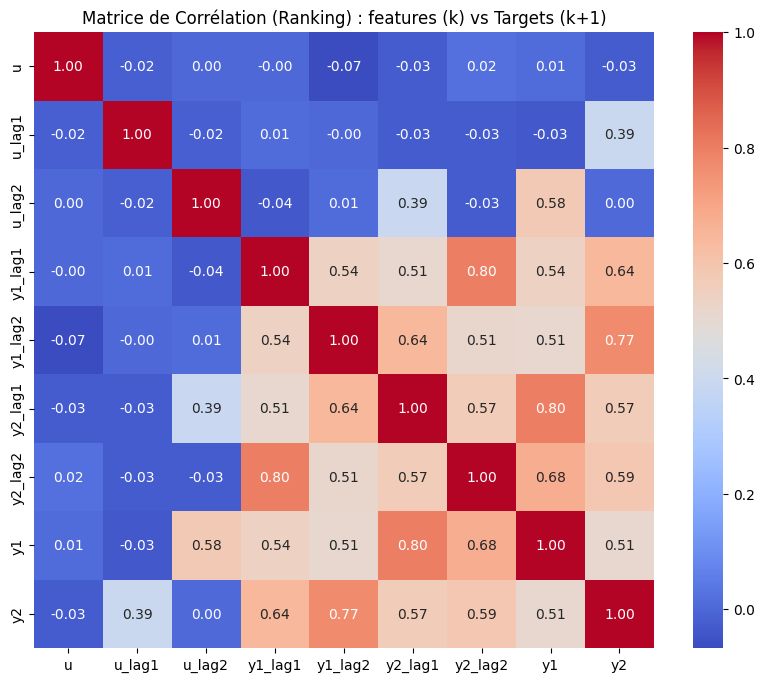

In [50]:
import seaborn as sns
# concaténation feature et cibles
df_analyse = pd.concat([X_train_chrono, Y_train_chrono], axis=1) #concaténation pour évaluer pertinence par rapport aux cibles
print(df_analyse.head())
correlation_matrix = df_analyse.corr() #Corrélation de Pearson
print("Correlation matrix:\n", correlation_matrix)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation (Ranking) : features (k) vs Targets (k+1)")
plt.show()

- on voit que y1 et y2 sont très corrélés (orange/rouge en bas à droite) -> très couplé
- **Tache 2 a)** on voit que corrélations pour lag2 plutôt élevées (0,6~0,7) donc cela nous permet de voir que l'information à lag2 (y(k-1)) impacte beaucoup à cible (y(k+1)). Il y a 2 pas d'écart entre cible et lag 2 et la corrélation reste forte malgré les deux pas d'écart donc na=2. Avec na=2, on dit au modèle que il faut utiliser y(k) et y(k-1) et donc le modèle aura plus de faciliter à réduire MSE.

Interressant de regarder lag 3 

Correlation matrix avec lag3:
                 u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
u        1.000000 -0.007150 -0.000599  0.024884 -0.030376 -0.012527  0.032717   
u_lag1  -0.007150  1.000000 -0.006768  0.017298  0.023834 -0.006423 -0.012488   
u_lag2  -0.000599 -0.006768  1.000000 -0.009831  0.018486  0.404961 -0.006466   
y1_lag1  0.024884  0.017298 -0.009831  1.000000  0.574844  0.533232  0.800143   
y1_lag2 -0.030376  0.023834  0.018486  0.574844  1.000000  0.649509  0.534235   
y2_lag1 -0.012527 -0.006423  0.404961  0.533232  0.649509  1.000000  0.584169   
y2_lag2  0.032717 -0.012488 -0.006466  0.800143  0.534235  0.584169  1.000000   
u_lag3   0.015160  0.000500 -0.007939  0.582127 -0.006551  0.022088  0.405513   
y1_lag3  0.018733 -0.030792  0.024271  0.526864  0.574703  0.780477  0.649702   
y2_lag3  0.007244  0.032139 -0.011863  0.697953  0.800051  0.602988  0.584527   
y1       0.016903 -0.009419  0.582214  0.572608  0.526204  0.800018  0.696822 

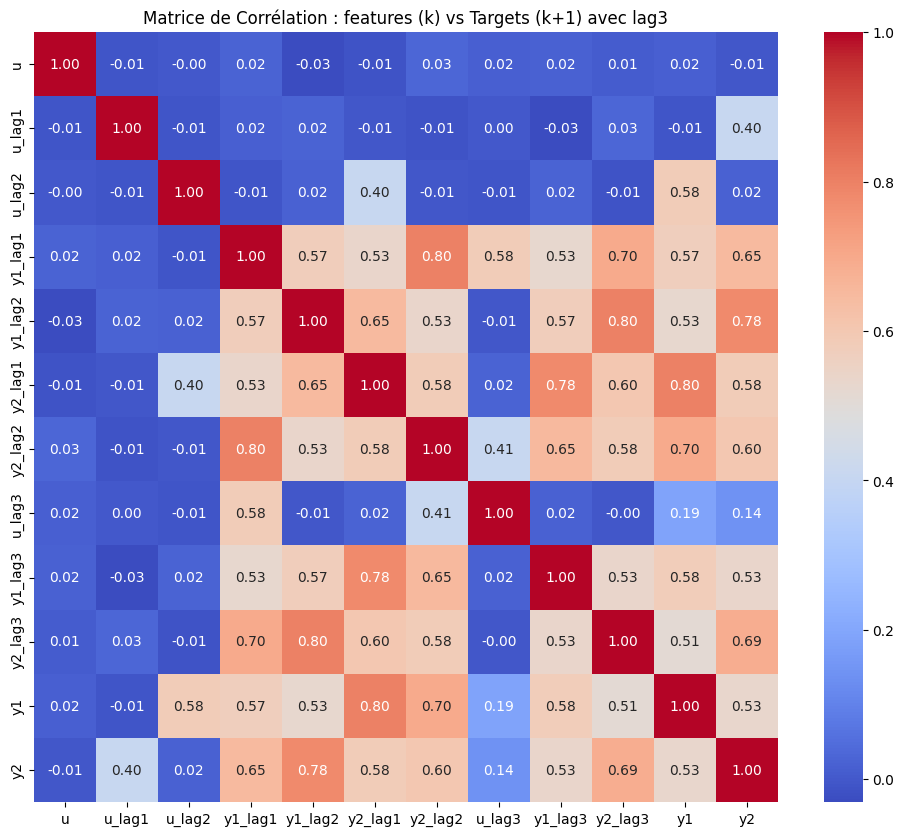

In [51]:
U_Narx1_reg['u_lag3'] = U_Narx1['u'].shift(3)
U_Narx1_reg['y1_lag3'] = Y_Narx1['y1'].shift(3)
U_Narx1_reg['y2_lag3'] = Y_Narx1['y2'].shift(3)

U_Narx1_reg = U_Narx1_reg.fillna(0)

df_analyse_lag3 = pd.concat([U_Narx1_reg,Y_Narx1_reg], axis=1)
correlation_matrix_lag3 = df_analyse_lag3.corr()
print("Correlation matrix avec lag3:\n", correlation_matrix_lag3)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_lag3, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation : features (k) vs Targets (k+1) avec lag3")
plt.show()

Avec Lag 3 on peut voir que l'on a eu une corrélation qui stagne. La différence entre lag 2 et lag 3 est minime donc on conserve **na=2**. Cela nous évite de rendre trop complexe le modèle. 

Donc pour éviter curse of dimensionality, on sélectionne le sous-ensemble {u, u_lag1, u_lag2, y1_lag1, y1_lag2 ...} car maximise sans ajouter de variables inutiles.

- Et pour les données réels à prédire ? 

On verra plus loin que la relation n'est pas linéaire. La
Matrice de corrélation n'est donc pas le plus optimal pour déterminer l'importance des features
C'est pourquoi on a décider d'utiliser la méthode Wrapper (justifier pk)

- Regression Linéaire Sur les données Narx1

In [52]:
X_train_narx1_chrono, Y_train_narx1_chrono, X_val_narx1_chrono, Y_val_narx1_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
# on enlève lag3 car dans la forumule théorique, elle n'y est pas
X_train_narx1_chrono = X_train_narx1_chrono.drop(columns=['u_lag3', 'y1_lag3', 'y2_lag3'])
X_val_narx1_chrono = X_val_narx1_chrono.drop(columns  =['u_lag3', 'y1_lag3', 'y2_lag3'])
print("Shape : ", X_train_narx1_chrono.shape, Y_train_narx1_chrono.shape, X_val_narx1_chrono.shape, Y_val_narx1_chrono.shape)

print("columns : ", X_train_narx1_chrono.columns.tolist())
print("head : ", X_train_narx1_chrono.head(5))


model_chrono_lag2 = LinearRegression()
model_chrono_lag2.fit(X_train_narx1_chrono, Y_train_narx1_chrono)
Y_pred_chrono_lag2 = model_chrono_lag2.predict(X_val_narx1_chrono)
nmse_chrono_lag2 = nmse(Y_val_narx1_chrono, Y_pred_chrono_lag2)
print("prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2")
print("NMSE Chronologique lag2 : ", nmse_chrono_lag2)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx1_chrono, Y_pred_chrono_lag2)))
# afficher les coefficients du modèle
coeff_df_lag2 = pd.DataFrame(model_chrono_lag2.coef_, columns=X_train_narx1_chrono.columns, index=Y_train_narx1_chrono.columns)
print("Coefficients du modèle lag2 :")
print(coeff_df_lag2)
print(f"\nIntercepts : {model_chrono_lag2.intercept_}")


Shape :  (800, 7) (800, 2) (200, 7) (200, 2)
columns :  ['u', 'u_lag1', 'u_lag2', 'y1_lag1', 'y1_lag2', 'y2_lag1', 'y2_lag2']
head :            u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
1  1.490142  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000
2 -0.414793  1.490142  0.000000  0.559742  0.000000  0.369853  0.000000
3  1.943066 -0.414793  1.490142  0.385331  0.559742  0.570222  0.369853
4  4.569090  1.943066 -0.414793  1.451077  0.385331  0.730173  0.570222
prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2
NMSE Chronologique lag2 :  0.16069476033247962
RMSE 0.6385793870239005
Coefficients du modèle lag2 :
           u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2
y1  0.006470 -0.000601  0.275170 -0.055476  0.088339  0.302544  0.584376
y2  0.009264  0.202613  0.003052  0.211195  0.518788  0.034490  0.105198

Inte

Ici on a une regression linéaire. Le choix des features a été faite de manière aléatoire dans 
un premier temps (On a pris lag 3). Les résultarts sont cohérents avec les résultats théoriques 
de la formule de Narx1. On retrouve des coefficients correctes devant les termes linéaires. 
Cependant, il est totalement logique qu'un modèle linéaire interprète mal les signaux sinusoidales

Dans la prochaine regression, on va ajouter une colonne en sinus 
Le modele deviendra donc : 
    y1 = 0.5y2(k−2) + sin(y2(k)) + 0.3u(k−2)
    y2 = 0.5y1(k−2) + sin(y1(k-1)) + 0.2u(k-1)



In [53]:
U_Narx1_reg['sin(y2_lag1)'] = np.sin(U_Narx1_reg['y2_lag1'])
U_Narx1_reg['sin(y1_lag1)'] = np.sin(U_Narx1_reg['y1_lag1'])

# on refait la regression linéaire en ajoutant les termes sin(y2_lag1) et sin(y1_lag1) qui sont présents dans les formules théoriques
X_train_narx1_chrono, Y_train_narx1_chrono, X_val_narx1_chrono, Y_val_narx1_chrono = split_train_val(U_Narx1_reg, Y_Narx1_reg, methode="chronologique", val_size=0.2)
X_train_narx1_chrono = X_train_narx1_chrono.drop(columns=['u_lag3', 'y1_lag3', 'y2_lag3'])
X_val_narx1_chrono = X_val_narx1_chrono.drop(columns  =['u_lag3', 'y1_lag3', 'y2_lag3'])
print("Shape : ", X_train_narx1_chrono.shape, Y_train_narx1_chrono.shape, X_val_narx1_chrono.shape, Y_val_narx1_chrono.shape)
model_chrono_lag2_sin = LinearRegression()
model_chrono_lag2_sin.fit(X_train_narx1_chrono, Y_train_narx1_chrono)
Y_pred_chrono_lag2_sin = model_chrono_lag2_sin.predict(X_val_narx1_chrono)
nmse_chrono_lag2_sin = nmse(Y_val_narx1_chrono, Y_pred_chrono_lag2_sin)
print("prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2 + les termes sin")
print("NMSE Chronologique lag2 + sin : ", nmse_chrono_lag2_sin)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx1_chrono, Y_pred_chrono_lag2_sin)))
# afficher les coefficients du modèle
coeff_df_lag2_sin = pd.DataFrame(model_chrono_lag2_sin.coef_, columns=X_train_narx1_chrono.columns, index=Y_train_narx1_chrono.columns)
print("Coefficients du modèle lag2 + sin :")
print(coeff_df_lag2_sin)
print(f"\nIntercepts : {model_chrono_lag2_sin.intercept_}")

Shape :  (800, 9) (800, 2) (200, 9) (200, 2)
prediction en utilisant toujours les lignes justes et non les lignes issues de la prédiction précédente lag2 + les termes sin
NMSE Chronologique lag2 + sin :  0.0630309416719485
RMSE 0.3999364020704379
Coefficients du modèle lag2 + sin :
           u    u_lag1    u_lag2   y1_lag1   y1_lag2   y2_lag1   y2_lag2  \
y1  0.000486 -0.003742  0.299172 -0.016495  0.020154 -0.021336  0.518612   
y2  0.005044  0.216143  0.004008 -0.007853  0.506417 -0.024075  0.000454   

    sin(y2_lag1)  sin(y1_lag1)  
y1      0.996400      0.014786  
y2      0.050975      1.024601  

Intercepts : [0.00973033 0.02827756]


Commen attendu, on a des résultats presque parfaits.

Cependant, on a utilisé les vrais valeurs pour prédire l'état K+1 et non nos prédictions.
Après discussions dans le groupe, on a décidé de commencé par une approche où on utilise nos prédictions 
de manière récursives. 
Il a été aussi été deiscuté de l'idée de faire des prédictions par blocs pour essayer de limiter 
l'exploion de l'erreur.

Prédiction à l'instant 0 : [1.09703038 1.5791977 ], Valeur réelle : [2.03287641 1.81268103]
Prédiction à l'instant 1 : [1.23855131 0.87605556], Valeur réelle : [0.86989198 1.54995987]
Prédiction à l'instant 2 : [1.21083702 1.59374819], Valeur réelle : [1.67875901 1.8678011 ]
Prédiction à l'instant 3 : [1.79561335 0.75343347], Valeur réelle : [2.32591455 1.0456867 ]
Prédiction à l'instant 4 : [0.71338996 1.25233776], Valeur réelle : [1.09283142 0.74301607]
Prédiction à l'instant 5 : [0.99186133 0.9229229 ], Valeur réelle : [1.64469064 2.28347497]
Prédiction à l'instant 6 : [0.61411712 0.47666799], Valeur réelle : [0.9726822  0.82791476]
Prédiction à l'instant 7 : [0.36517763 0.58251009], Valeur réelle : [1.40661676 1.46063251]
Prédiction à l'instant 8 : [0.20575355 0.59528788], Valeur réelle : [1.36915833 1.87351034]
Prédiction à l'instant 9 : [0.73185311 0.0710938 ], Valeur réelle : [1.59109806 1.42859727]
Prédiction à l'instant 10 : [-0.08599263  1.07087848], Valeur réelle : [1.678700

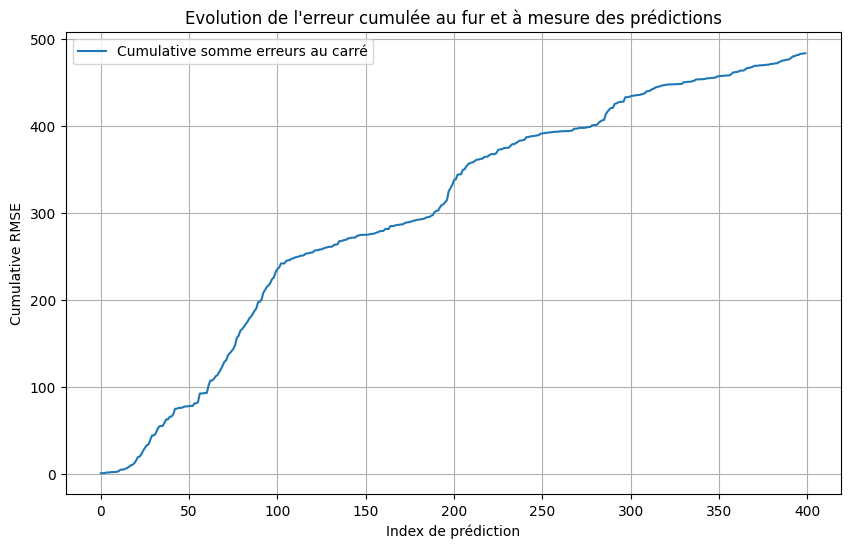

In [54]:
# A reverifier : et en faire une fonction si possible pour éviter les répétitions de code
# mais ca a l'air de fonctionner : si on ne met pas de bruits on tombe sur des resultats très proches
#de la regression en recupérant les lignes issues de la prédiction précédente, ce qui est cohérent avec les formules théoriques
# mais dès que l'on ajoute du bruit, les résultats sont catastrophiques

# On récupère l'ordre exact des colonnes que le modèle attend
ordered_features = model_chrono_lag2.feature_names_in_

X_val_narx1_chrono_pred = X_val_narx1_chrono.copy()
Y_val_narx1_chrono_pred = Y_val_narx1_chrono.copy()

for i in range(len(Y_val_narx1_chrono_pred)):

    if i > 0:
        prev_y1 = Y_val_narx1_chrono_pred.iloc[i-1]['y1']
        prev_y2 = Y_val_narx1_chrono_pred.iloc[i-1]['y2']

        # Mise à jour des lags
        X_val_narx1_chrono_pred.loc[X_val_narx1_chrono_pred.index[i], 'y1_lag1'] = prev_y1
        X_val_narx1_chrono_pred.loc[X_val_narx1_chrono_pred.index[i], 'y2_lag1'] = prev_y2

        # Mise à jour des sinus
        X_val_narx1_chrono_pred.loc[X_val_narx1_chrono_pred.index[i], 'sin(y1_lag1)'] = np.sin(prev_y1)
        X_val_narx1_chrono_pred.loc[X_val_narx1_chrono_pred.index[i], 'sin(y2_lag1)'] = np.sin(prev_y2)

    if i > 1:
        prev2_y1 = Y_val_narx1_chrono_pred.iloc[i-2]['y1']
        prev2_y2 = Y_val_narx1_chrono_pred.iloc[i-2]['y2']

        X_val_narx1_chrono_pred.loc[X_val_narx1_chrono_pred.index[i], 'y1_lag2'] = prev2_y1
        X_val_narx1_chrono_pred.loc[X_val_narx1_chrono_pred.index[i], 'y2_lag2'] = prev2_y2

    # On extrait la ligne ET on remet les colonnes dans l'ordre du .fit()
    current_x = X_val_narx1_chrono_pred.iloc[[i]][ordered_features]

    # Prédiction
    Y_val_narx1_chrono_pred.iloc[i] = model_chrono_lag2.predict(current_x)[0]
    print(f"Prédiction à l'instant {i} : {Y_val_narx1_chrono_pred.iloc[i].values}, Valeur réelle : {Y_val_narx1_chrono.iloc[i].values}")


nmse_chrono_lag2_pred = nmse(Y_val_narx1_chrono, Y_val_narx1_chrono_pred)
print("prediction en utilisant les lignes issues de la prédiction précédente lag2")
print("NMSE Chronologique lag2 avec prédiction précédente : ", nmse_chrono_lag2_pred)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx1_chrono, Y_val_narx1_chrono_pred)))


# affichier l'évolution des erreurs cumulées au fur et à mesure des prédictions, pour voir si l'erreur s'accumule ou pas

cumulative_errors = np.cumsum((Y_val_narx1_chrono.values - Y_val_narx1_chrono_pred.values)**2)
plt.figure(figsize=(10, 6))
plt.plot(cumulative_errors, label='Cumulative somme erreurs au carré')
plt.title('Evolution de l\'erreur cumulée au fur et à mesure des prédictions')
plt.xlabel('Index de prédiction') # 2*200 car on a 200 lignes de val et 2 cibles (y1 et y2)
plt.ylabel('Cumulative RMSE')
plt.legend()
plt.grid()
plt.show()

En enlevant les sinus lors de la regression linéaire qui sont difficilement predictibles, 
et en comparant les résultats d'inférence avec nos valeurs prédites ou les vrais valeurs,
on se rend compte que l'erreur a augmenté. On n'a pas une explosion énorme des erreurs puisque les valeurs 
du sinus sont bornées et sont de moyennes nulles et que notre modèle reste donc très bon
Mais on se rend bien compte que dans d'autres cas, cela peut être un problème majeur...

###  modèle : Random Forest pour NARX1

Bien que  la Régression Linéaire soit le modèle naturel pour NARX1 (système quasi-linéaire), l utilisation de Random Forest permet de tester si des interactions non-linéaires non explicites ou des dépendances complexes peuvent être capturées pour améliorer la précision (NMSE).

### chercons les hyperparamètres

-n_estimators : Le nombre d'arbres. Plus il y en a, mieux c'est, mais c'est plus lent

-max_depth : La profondeur maximale des arbres. Trop profond = surapprentissage (overfitting). Pas assez profond = sous-apprentissage.

Trouver la meilleure profondeur (max_depth) pour NARX1

In [ ]:

depth_range = list(range(1, 31)) 
mse_train_narx1 = []
mse_val_narx1 = []

for d in tqdm(depth_range):
    rf = RandomForestRegressor(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train_narx1_chrono, Y_train_narx1_chrono)
    
    # Calcul des erreurs
    mse_train_narx1.append(mean_squared_error(Y_train_narx1_chrono, rf.predict(X_train_narx1_chrono)))
    mse_val_narx1.append(mean_squared_error(Y_val_narx1_chrono, rf.predict(X_val_narx1_chrono)))

# Graphique de comparaison
plt.figure(figsize=(10, 5))
plt.plot(depth_range, mse_train_narx1, label="Train MSE")
plt.plot(depth_range, mse_val_narx1, marker='o', label="Validation MSE")
plt.title("NARX1 : MSE vs max_depth (Random Forest)")
plt.xlabel("Profondeur maximale (max_depth)")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

 67%|██████████████████████████████████████████████████████▋                           | 20/30 [00:24<00:14,  1.46s/it]

L'analyse de l'évolution du MSE en fonction de la profondeur montre qu'au-delà de max_depth=7, l'erreur de validation stagne alors que l'erreur d'entraînement continue de diminuer. Cela indique que le modèle commence à surapprendre le bruit des données sans améliorer sa capacité de généralisation. Pour la suite, nous fixons la profondeur à 7 pour garantir la stabilité du modèle lors de la simulation à long terme.

### Trouver le plus adapté n_estimators pour NARX1

100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [00:16<00:00,  1.11it/s]


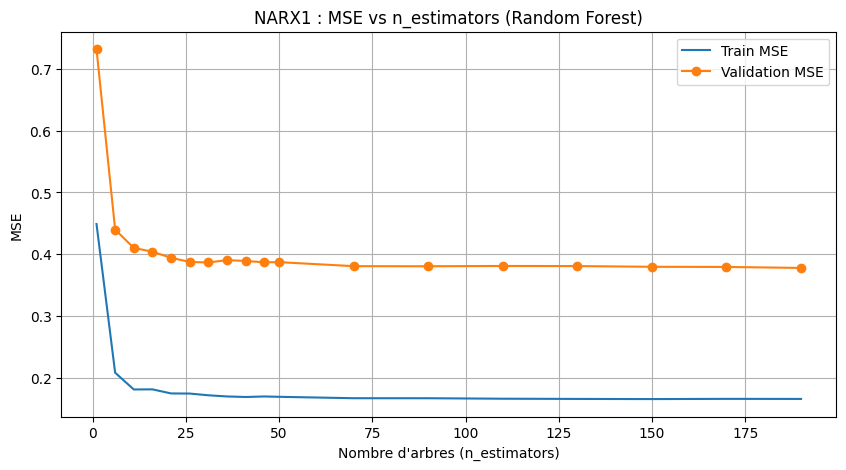

In [38]:
estimators_range = list(range(1, 51, 5)) + list(range(50, 201, 20))
mse_train_est = []
mse_val_est = []

for n in tqdm(estimators_range):
    
    rf = RandomForestRegressor(n_estimators=n, max_depth=7, random_state=42)
    rf.fit(X_train_narx1_chrono, Y_train_narx1_chrono)
    
    mse_train_est.append(mean_squared_error(Y_train_narx1_chrono, rf.predict(X_train_narx1_chrono)))
    mse_val_est.append(mean_squared_error(Y_val_narx1_chrono, rf.predict(X_val_narx1_chrono)))

plt.figure(figsize=(10, 5))
plt.plot(estimators_range, mse_train_est, label="Train MSE")
plt.plot(estimators_range, mse_val_est, marker='o', label="Validation MSE")
plt.title("NARX1 : MSE vs n_estimators (Random Forest)")
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
rf_narx1 = RandomForestRegressor(n_estimators=75, max_depth=7, random_state=42)

#Entraînement
rf_narx1.fit(X_train_narx1_chrono, Y_train_narx1_chrono)

#Prédiction sur l'ensemble de validation
Y_pred_rf_narx1 = rf_narx1.predict(X_val_narx1_chrono)

#Calcul du NMSE
nmse_rf_narx1 = nmse(Y_val_narx1_chrono, Y_pred_rf_narx1)

print("Résultats:")
print("NMSE Chronologique NARX1 :", nmse_rf_narx1)
print("RMSE :" ,np.sqrt(mean_squared_error(Y_val_narx1_chrono, Y_pred_rf_narx1)))

Résultats:
NMSE Chronologique NARX1 : 0.14992421251628724
RMSE : 0.6168078975078273


### préparation des données en blocs

In [44]:
def prepare_block_data(U, Y, u_size):
    X, Y_block = [], []
    # On s'arrête assez tôt pour que le dernier bloc de taille u_size rentre dans les données
    for i in range(2, len(Y) - u_size):
        # Features : lags 1 et 2 
        features = [
            Y.iloc[i-1]['y1'], Y.iloc[i-2]['y1'],
            Y.iloc[i-1]['y2'], Y.iloc[i-2]['y2'],
            U.iloc[i-1]['u'],  U.iloc[i-2]['u']
        ]
        X.append(features)
        
        # Cible : le bloc de u_size * 2 sorties 
        target = Y.iloc[i : i + u_size][['y1', 'y2']].values.flatten()
        Y_block.append(target)
        
    return np.array(X), np.array(Y_block)

## Travail sur NARX2 
- modèle non linéaire donc pourquoi pas essayer une régression linéaire mais cela risque d'être 
peu concluant 
- essayer les modèles Xgboost/RandomForest qui sont en général très performants sur ce style 
de pb 
- Peut être les KNN etc...
- Pour ces méthodes, il y a un vrai choix d'hyperparamètres à faire donc il est important d'utiliser la 
cross-validation

### Préparation des données

In [14]:
###########
X_train_narx2_chrono, Y_train_narx2_chrono, X_val_narx2_chrono, Y_val_narx2_chrono = split_train_val(U_Narx2, Y_Narx2, methode="chronologique", val_size=0.2)
print("Shape : ", X_train_narx2_chrono.shape, Y_train_narx2_chrono.shape, X_val_narx2_chrono.shape, Y_val_narx2_chrono.shape)
# on ajoute les lags 1, 2, 3 pour les features et les cibles
X_train_narx2_chrono['u1_lag1'] = X_train_narx2_chrono['u1'].shift(1)
X_train_narx2_chrono['u1_lag2'] = X_train_narx2_chrono['u1'].shift(2)
X_train_narx2_chrono['u1_lag3'] = X_train_narx2_chrono['u1'].shift(3)
X_train_narx2_chrono['u2_lag1'] = X_train_narx2_chrono['u2'].shift(1)
X_train_narx2_chrono['u2_lag2'] = X_train_narx2_chrono['u2'].shift(2)
X_train_narx2_chrono['u2_lag3'] = X_train_narx2_chrono['u2'].shift(3)
X_train_narx2_chrono['y1_lag1'] = Y_train_narx2_chrono['y1'].shift(1)
X_train_narx2_chrono['y1_lag2'] = Y_train_narx2_chrono['y1'].shift(2)
X_train_narx2_chrono['y1_lag3'] = Y_train_narx2_chrono['y1'].shift(3)
X_train_narx2_chrono['y2_lag1'] = Y_train_narx2_chrono['y2'].shift(1)
X_train_narx2_chrono['y2_lag2'] = Y_train_narx2_chrono['y2'].shift(2)
X_train_narx2_chrono['y2_lag3'] = Y_train_narx2_chrono['y2'].shift(3)
X_train_narx2_chrono = X_train_narx2_chrono.fillna(0)
print(X_train_narx2_chrono.head())
print(X_train_narx2_chrono.columns)

# de même ^pour les données de val
X_val_narx2_chrono['u1_lag1'] = X_val_narx2_chrono['u1'].shift(1)
X_val_narx2_chrono['u1_lag2'] = X_val_narx2_chrono['u1'].shift(2)
X_val_narx2_chrono['u1_lag3'] = X_val_narx2_chrono['u1'].shift(3)
X_val_narx2_chrono['u2_lag1'] = X_val_narx2_chrono['u2'].shift(1)
X_val_narx2_chrono['u2_lag2'] = X_val_narx2_chrono['u2'].shift(2)
X_val_narx2_chrono['u2_lag3'] = X_val_narx2_chrono['u2'].shift(3)
X_val_narx2_chrono['y1_lag1'] = Y_val_narx2_chrono['y1'].shift(1)
X_val_narx2_chrono['y1_lag2'] = Y_val_narx2_chrono['y1'].shift(2)
X_val_narx2_chrono['y1_lag3'] = Y_val_narx2_chrono['y1'].shift(3)
X_val_narx2_chrono['y2_lag1'] = Y_val_narx2_chrono['y2'].shift(1)
X_val_narx2_chrono['y2_lag2'] = Y_val_narx2_chrono['y2'].shift(2)
X_val_narx2_chrono['y2_lag3'] = Y_val_narx2_chrono['y2'].shift(3)

X_val_narx2_chrono = X_val_narx2_chrono.fillna(0)
print(Y_val_narx2_chrono.shape)
print(X_val_narx2_chrono.shape)
print(X_train_narx2_chrono.shape)
print("valeur manquante : ", Y_train_narx2_chrono.isna().sum().sum())
# Les jeux de données sont prêts, on peut appliquer le modèle


Shape :  (800, 2) (800, 2) (200, 2) (200, 2)
         u1        u2   u1_lag1   u1_lag2   u1_lag3   u2_lag1   u2_lag2  \
0  0.049671  0.139936  0.000000  0.000000  0.000000  0.000000  0.000000   
1 -0.013826  0.092463  0.049671  0.000000  0.000000  0.139936  0.000000   
2  0.064769  0.005963 -0.013826  0.049671  0.000000  0.092463  0.139936   
3  0.152303 -0.064694  0.064769 -0.013826  0.049671  0.005963  0.092463   
4 -0.023415  0.069822  0.152303  0.064769 -0.013826 -0.064694  0.005963   

    u2_lag3   y1_lag1   y1_lag2   y1_lag3   y2_lag1   y2_lag2   y2_lag3  
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  
1  0.000000 -0.006752  0.000000  0.000000 -0.001445  0.000000  0.000000  
2  0.000000  0.132011 -0.006752  0.000000  0.046592 -0.001445  0.000000  
3  0.139936  0.073527  0.132011 -0.006752 -0.011693  0.046592 -0.001445  
4  0.092463  0.005968  0.073527  0.132011  0.055486 -0.011693  0.046592  
Index(['u1', 'u2', 'u1_lag1', 'u1_lag2', 'u1_lag3', 'u2_lag1

### Premier modèle : Xgboost

In [15]:
#calcule de NMSE
def nmse(y_original,y_pred):
    mse=mean_squared_error(y_original,y_pred)
    variance=np.var(y_original)
    return mse/variance

model_chrono_narx2 = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=2, learning_rate=0.2, random_state=42)
model_chrono_narx2.fit(X_train_narx2_chrono, Y_train_narx2_chrono)
Y_pred_chrono_narx2 = model_chrono_narx2.predict(X_val_narx2_chrono)
nmse_chrono_narx2 = nmse(Y_val_narx2_chrono, Y_pred_chrono_narx2)
print("NMSE Chronologique NARX2 : ", nmse_chrono_narx2)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx2_chrono, Y_pred_chrono_narx2)))

NMSE Chronologique NARX2 :  0.01462891336749826
RMSE 0.011647552659586795


### Deuxième modèle : Random Forest
Nous avons plusieurs choix de modèles possible, nous avons déjà écarté KNN car en simulation longue, c'est très instable. 
Ensuite notre choix c'est porté sur Random Forest. 

Random Forest : Ici c'est un modèle Bagging (la moyenne de plusieurs arbres indépendants) alors que XGBoost est un modèle de boosting (chaque arbre corrige l'erreur du precédent). Comme on est en simulation récursive, Random Forest peut permettre d'être peut-être plus stable. Donc avec ce modèle , on recherche de la robustesse. 
Cela peut nous permettre de de comparer deux modèles d'arbre qui ont une philosophie différente. 

je cherche à trouver comment les hyperparamètres influencent le mse.  

100%|██████████████████████████████████████████████████████████████████████████████████| 49/49 [01:30<00:00,  1.84s/it]


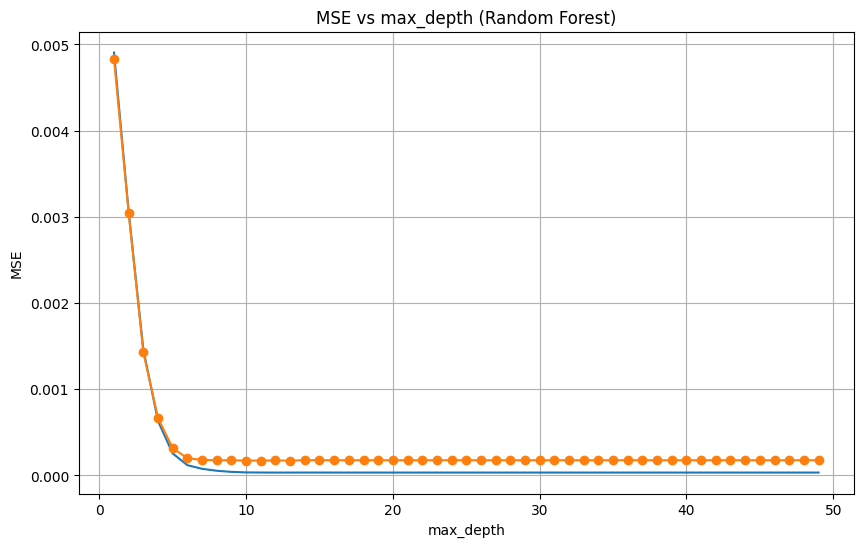

In [39]:
depth_range=list(range(1,50))
mse_train=[]
mse_val=[]

for d in tqdm(depth_range):
    rf=RandomForestRegressor(n_estimators=100,max_depth=d,random_state=42)
    rf.fit(X_train_narx2_chrono, Y_train_narx2_chrono)
    mse_train.append(mean_squared_error(Y_train_narx2_chrono, rf.predict(X_train_narx2_chrono)))
    mse_val.append(mean_squared_error(Y_val_narx2_chrono, rf.predict(X_val_narx2_chrono)))

plt.figure(figsize=(10, 6))
plt.plot(depth_range,mse_train,label="Train")
plt.plot(depth_range,mse_val,marker='o',label="Val")
plt.title("MSE vs max_depth (Random Forest)")
plt.xlabel("max_depth")
plt.ylabel("MSE")
plt.grid("on")
plt.show()

- **Train (blue)** : à mesure que la max_depths augmente, plus le modèle mémorise les données.
- **Validation (orange)** : De 1 à 6, l'erreur chute drastiquement, le modèle apprend. Après 7, on observe un plateau. Augmenter la complexité ne permet plus d'améliorer la capacité du modèle à prédire les nouvelles données

**-> Conclusion :** Nous fixons max_depths=7 car cela minimise mse tout en conservant un modèle simple, ce qui va nous permettre d'éviter l'explosion d'erreur à long terme.

100%|██████████████████████████████████████████████████████████████████████████████████| 18/18 [00:22<00:00,  1.23s/it]


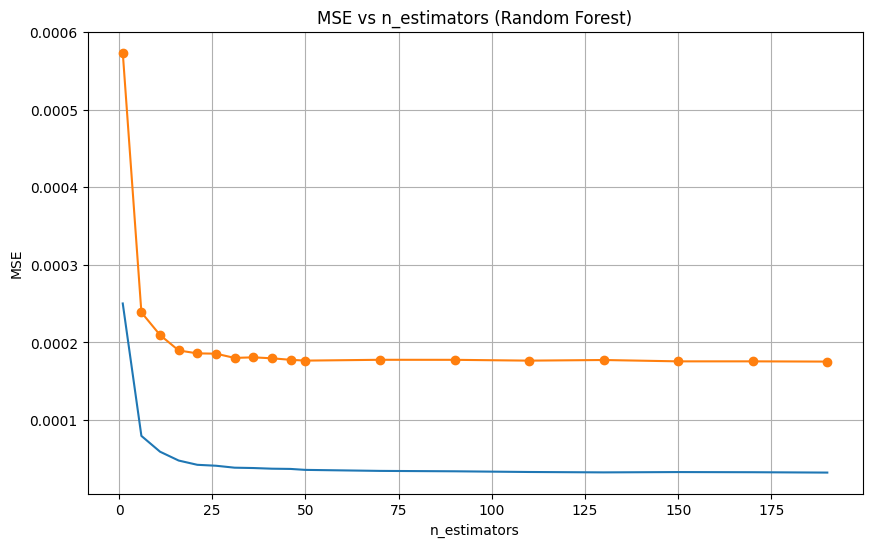

In [40]:
estimators_range=list(range(1, 50,5))+list(range(50, 201, 20))
mse_train=[]
mse_val=[]

for n in tqdm(estimators_range):
    rf=RandomForestRegressor(n_estimators=n,random_state=42)
    rf.fit(X_train_narx2_chrono, Y_train_narx2_chrono)
    mse_train.append(mean_squared_error(Y_train_narx2_chrono, rf.predict(X_train_narx2_chrono)))
    mse_val.append(mean_squared_error(Y_val_narx2_chrono, rf.predict(X_val_narx2_chrono)))

plt.figure(figsize=(10, 6))
plt.plot(estimators_range,mse_train,label="Train")
plt.plot(estimators_range,mse_val,marker='o',label="Val")
plt.title("MSE vs n_estimators (Random Forest)")
plt.xlabel("n_estimators")
plt.ylabel("MSE")
plt.grid("on")
plt.show()

On observe un chute de 0 à 20, c'est normal car c'est le moment où la forêt commence à moyenner les erreurs des arbres. Ensuite à partir de 50, cela stagne, l'ajout d'arbre ne réduit pas l'erreur. 

**-> Conclusion :** On fixe n_estimators=100, cela nous assure robustesse et est plus rapide que 200. 

In [41]:
from sklearn.ensemble import RandomForestRegressor

model_forest_narx2=RandomForestRegressor(n_estimators=100, max_depth=7,random_state=42)
model_forest_narx2.fit(X_train_narx2_chrono, Y_train_narx2_chrono)
Y_pred_forest_narx2=model_forest_narx2.predict(X_val_narx2_chrono)
nmse_forest_narx2=nmse(Y_val_narx2_chrono,Y_pred_forest_narx2)

print("NMSE Chronologique NARX2 : ", nmse_forest_narx2)
print("RMSE", np.sqrt(mean_squared_error(Y_val_narx2_chrono, Y_pred_forest_narx2)))


NMSE Chronologique NARX2 :  0.019482185468026204
RMSE 0.013441492229828662


### **Neurone network**

Normalization and standardization

In [33]:
from sklearn.preprocessing import StandardScaler
import torch

# input scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_narx2_chrono)
X_val_scaled = scaler_X.transform(X_val_narx2_chrono)

# outputs scaling
scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train_narx2_chrono)
Y_val_scaled = scaler_Y.transform(Y_val_narx2_chrono)

# conversion into tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train_scaled, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val_scaled, dtype=torch.float32)



Create object netwrk

In [36]:
import torch.nn as nn

class Narx_network(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim) # Input -> Hidden
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2) 
        self.fc3 = nn.Linear(hidden_dim // 2, output_dim) # Output

    def forward(self, x):
	x=self.fc1(x)
        x = torch.relu(x)
	x=self.fc2(x)
        x = torch.relu(x)
        x = self.fc3(x)
        return x


TabError: inconsistent use of tabs and spaces in indentation (<string>, line 11)

In [ ]:
import torch.optim as optim

input_dim = X_train_t.shape[1]
hidden_dim = 64  #explain
output_dim = 2

model_NN = Narx_network(input_dim, hidden_dim, output_dim)
criterion = nn.MSELoss(reduction='sum')

optimizer = optim.Adam(model_NN.parameters(), lr=0.001, weight_decay=1e-3) #explain


from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_t, Y_train_t)
val_dataset = TensorDataset(X_val_t, Y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) #explain batch size


loop training (early stopping)

In [ ]:
max_epochs = 500
patience = 20
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_path = "best_model.pth"

train_history = []
val_history = []

for epoch in range(max_epochs):
    # Phase d'entraînement
    model_NN.train()
    running_train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model_NN(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    
    avg_train_loss = running_train_loss / len(train_loader.dataset)
    train_history.append(avg_train_loss)

    # Phase de validation
    model_NN.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for Xv_batch, yv_batch in val_loader:
            val_preds = model_NN(Xv_batch)
            val_loss = criterion(val_preds, yv_batch)
            running_val_loss += val_loss.item()
    
    avg_val_loss = running_val_loss / len(val_loader.dataset)
    val_history.append(avg_val_loss)
    
    # print every 10
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} -> Train MSE : {avg_train_loss:.4f} and Val MSE : {avg_val_loss:.4f}")

    # earling stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model_NN.state_dict(), best_model_path)
    else:
        epochs_no_improve =epochs_no_improve+ 1
        if epochs_no_improve >= patience:
            print(f"Early stopping {epoch+1}")
            break

## Travail sur les données réelles

- essayer le modèle de régression même si peu de chances que cela focntionne
- résumer l'ensemble des connaissances apprises lors des 2 expériences NARX1 et 2
C'est à dire :
    - choix des hyperparamètres (cross-validation)
    - choix des lags (feature selection)
    - choix de la méthode d'inférence pour éviter l'explosion des erreurs

A mon sens, cela vient après l'ensemble du travail fait sur des données connues.

       Ytr0      Ytr1
0  0.000000  0.000000
1  0.042170  0.720120
2 -0.016521 -0.222306
3 -0.235810  0.020866
4 -0.080339 -0.352666
Index(['Ytr0', 'Ytr1'], dtype='str')
Nombre de features :  14


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:26<00:00,  1.86s/it]


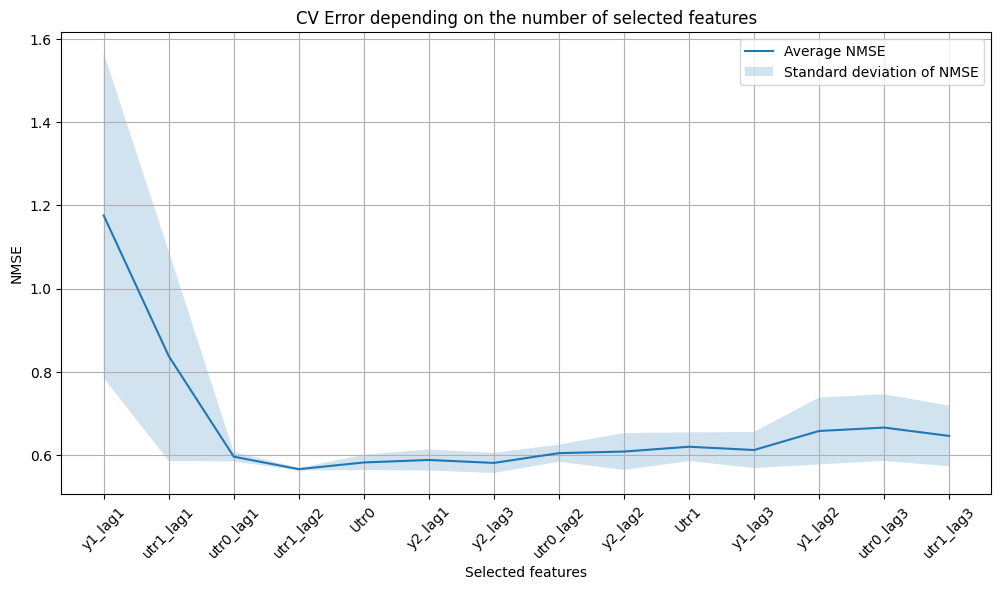

In [35]:
X_val = X[800:1000]
Y_val = Y[800:1000]
X_train = X[:800]
Y_train = Y[:800]
print(Y_train.head())
from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

print(Y_train.columns)
X_train["utr0_lag1"] = X_train['Utr0'].shift(1)
X_train["utr0_lag2"] = X_train['Utr0'].shift(2)
X_train["y1_lag1"] = Y_train['Ytr0'].shift(1)
X_train["y1_lag2"] = Y_train['Ytr0'].shift(2)
X_train["y2_lag1"] = Y_train['Ytr1'].shift(1)
X_train["y2_lag2"] = Y_train['Ytr1'].shift(2)
X_train["y1_lag3"] = Y_train['Ytr0'].shift(3)
X_train["y2_lag3"] = Y_train['Ytr1'].shift(3)
X_train["utr0_lag3"] = X_train['Utr0'].shift(3)
X_train["utr1_lag1"] = X_train['Utr1'].shift(1)
X_train["utr1_lag2"] = X_train['Utr1'].shift(2)
X_train["utr1_lag3"] = X_train['Utr1'].shift(3)

X_train = X_train.fillna(0)



#wrapper initialization
selected=[] #indices des variables retenues
CV_err=[] #evolution de erreur moyyenne de cross validation
std_err=[] #evolution ecart type
n=X_train.shape[1]
print("Nombre de features : ", n)
feature_name=list(X_train.columns)

kf=TimeSeriesSplit(n_splits=2) #pour ne pas mélanger les données car temporelles

#utilise le bloc train pour cross validation
X_fs=X_train
Y_fs=Y_train["Ytr0"].values

#boucle Forward selection (greedy)
for round_i in tqdm(range(n)):
    candidates=list(set(range(n))-set(selected))
    CV_err_temp=[]
    round_fold_errors=[] #permet de stocker les erreurs de chaque fold par candidat

    for c in candidates:
        features_to_include=selected+[c] #on teste ensemble actuel avec un new candidat
        fold_errors=[]

        #cross validation intern sur 5 périodes dif
        for train_index, test_index in kf.split(X_fs):
            X_tr,X_ts=X_fs.iloc[train_index, features_to_include],X_fs.iloc[test_index, features_to_include] #spéaration train et test
            Y_tr,Y_ts=Y_fs[train_index],Y_fs[test_index]

            #baseline
            model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=3, learning_rate=0.1)
            model.fit(X_tr,Y_tr)
            #prediction
            Y_hat_ts=model.predict(X_ts)
            fold_errors.append(nmse(Y_ts,Y_hat_ts))
        #moyenne des erreurs
        CV_err_temp.append(np.mean(fold_errors))
        round_fold_errors.append(fold_errors)

#selection meilleur candidat
    best_index=np.argmin(CV_err_temp)
    best_candidate=candidates[best_index]

    selected.append(best_candidate)
    CV_err.append(CV_err_temp[best_index])
    std_err.append(np.std(round_fold_errors[best_index]))

x=list(range(1,n+1))
errors=np.array(CV_err)
stds=np.array(std_err)
labels=[feature_name[i] for i in selected]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, errors, label="Average NMSE")
ax.fill_between(x, errors - stds, errors + stds, alpha=0.2, label="Standard deviation of NMSE")
ax.set_title("CV Error depending on the number of selected features")
ax.set_xlabel("Selected features")
ax.set_ylabel("NMSE")
ax.set_xticks(ticks=x, labels=labels, rotation=45)
plt.legend()
plt.grid("on")
plt.show()


- tests des pilotes : ok 
- 1 modele en plus pour NARX1, essayer et compararer ok
- 2 modèles pour NArx2 en plus des tests (xgboost, un autre pour comparer) ok



--> comment on prédit le futur à long terme ? 
- soit on prédit tous les futurs d'un coup (1000 pts) (risque d'être mauvais)
"entrainer 1000 modèles : un pour entrainer yk+1, un pour yk+2 ... etc 
- soit de manière récursive (points par points) (explosion de l'erreur)
- soit block par blocks : eurielle
"entrainer u modèles (u dépend du nb des blocs) pour prédire yk+1,...etc, yk+u (c'est la fin d'un bloc)
-on reprend les valeurs trouvées pour le bloc qui suit
(top : c'est de choisir u par validation croisée)


- Reseau de neuronnes


- Reutiliser ce qui a été fai tpour narx2, on l'applique aux données réelles
